In [13]:
# Imports and Setup
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.applications import VGG16

import optuna
import shap
import cv2

from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, recall_score

# Simplify GPU/CPU messages
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3' # Suppress TF warnings (including GPU lack warning)
tf.random.set_seed(42)
np.random.seed(42)

sns.set_theme(style="whitegrid")

In [14]:
# 1. Load and Preprocess CIFAR-10 (Subset for local execution speed)
import warnings
print("Loading CIFAR-10 data...")
with warnings.catch_warnings():
    warnings.simplefilter('ignore') # ignore all warnings broadly to suppress numpy numpy/keras interaction warnings
    (X_train_full, y_train_full), (X_test_full, y_test_full) = keras.datasets.cifar10.load_data()

# Ensure fast turnaround while meeting requirements: taking 10k train, 2k test
N_TRAIN = 10000
N_TEST = 2000

X_train, y_train = X_train_full[:N_TRAIN], y_train_full[:N_TRAIN]
X_test, y_test = X_test_full[:N_TEST], y_test_full[:N_TEST]

# Normalize 0..255 to 0..1
X_train_norm = X_train.astype('float32') / 255.0
X_test_norm = X_test.astype('float32') / 255.0

# Flattned versions for MLP
X_train_flat = X_train_norm.reshape((N_TRAIN, -1))
X_test_flat = X_test_norm.reshape((N_TEST, -1))

# One-hot encoding
y_train_oh = keras.utils.to_categorical(y_train, 10)
y_test_oh = keras.utils.to_categorical(y_test, 10)

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

print(f"X_train shape: {X_train.shape} | X_train_flat: {X_train_flat.shape}")
print(f"X_test shape: {X_test.shape}")

Loading CIFAR-10 data...
X_train shape: (10000, 32, 32, 3) | X_train_flat: (10000, 3072)
X_test shape: (2000, 32, 32, 3)


In [15]:
# 2. Define Model Architectures
def build_mlp(dropout_rate=0.3, weight_decay=1e-4, lr=1e-3):
    """Deep MLP with 4 Hidden Layers of 512 + BatchNorm + Dropout"""
    model = models.Sequential()
    model.add(layers.Input(shape=(3072,)))
    
    for _ in range(4):
        model.add(layers.Dense(512, kernel_regularizer=regularizers.l2(weight_decay)))
        model.add(layers.BatchNormalization())
        model.add(layers.ReLU())
        model.add(layers.Dropout(dropout_rate))
        
    model.add(layers.Dense(10, activation='softmax'))
    
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=lr),
                  loss='categorical_crossentropy', metrics=['accuracy'])
    return model

data_augmentation = keras.Sequential([
    layers.Input(shape=(32, 32, 3)),
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomCrop(32, 32)
])

def build_cnn(dropout_rate=0.25, lr=1e-3):
    """CNN with Data Augmentation + 3 Conv Blocks + BatchNorm + Pooling + Dropout"""
    model = models.Sequential()
    model.add(data_augmentation)
    
    # Block 1
    model.add(layers.Conv2D(32, (3,3), padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.ReLU())
    model.add(layers.MaxPooling2D((2,2)))
    model.add(layers.Dropout(dropout_rate))
    
    # Block 2
    model.add(layers.Conv2D(64, (3,3), padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.ReLU())
    model.add(layers.MaxPooling2D((2,2)))
    model.add(layers.Dropout(dropout_rate))
    
    # Block 3
    model.add(layers.Conv2D(128, (3,3), padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.ReLU())
    model.add(layers.MaxPooling2D((2,2)))
    model.add(layers.Dropout(dropout_rate))
    
    model.add(layers.Flatten())
    model.add(layers.Dense(128, activation='relu'))
    model.add(layers.Dropout(dropout_rate))
    model.add(layers.Dense(10, activation='softmax'))
    
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=lr),
                  loss='categorical_crossentropy', metrics=['accuracy'])
    return model

def build_transfer_learning(lr=1e-4):
    """Pretrained VGG16 with Data Augmentation and Fine-tuning top 2 dense layers"""
    base_model = VGG16(weights='imagenet', include_top=False, input_shape=(32, 32, 3))
    # Freeze base model
    base_model.trainable = False
    
    model = models.Sequential()
    model.add(data_augmentation)
    # Important: preprocess input expected by vgg16, for CIFAR it expects 0-255 or standardized, 
    # but we normalized to 0-1. VGG expects roughly BGR -127 to +127 but 0-1 works enough for fine tuning a new head.
    model.add(base_model) 
    model.add(layers.Flatten())
    
    # Custom Head (last 2 layers to fine-tune as requested)
    model.add(layers.Dense(256, activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.Dropout(0.5))
    model.add(layers.Dense(10, activation='softmax'))
    
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=lr),
                  loss='categorical_crossentropy', metrics=['accuracy'])
    return model

In [16]:
# 3. Hyperparameter Optimisation: Optuna (Demo on MLP for 1 fast epoch)
import logging
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    # Optuna parameter space
    lr = trial.suggest_float('lr', 1e-4, 1e-2, log=True)
    dropout_rate = trial.suggest_float('dropout_rate', 0.2, 0.5)
    weight_decay = trial.suggest_float('weight_decay', 1e-5, 1e-3, log=True)
    batch_size = trial.suggest_categorical('batch_size', [32, 64, 128])
    
    model = build_mlp(dropout_rate=dropout_rate, weight_decay=weight_decay, lr=lr)
    
    # Train very fast for trial
    history = model.fit(X_train_flat, y_train_oh, 
                        validation_split=0.2,
                        epochs=1, batch_size=batch_size, verbose=0)
    
    val_acc = history.history['val_accuracy'][0]
    return val_acc

# Quick Search (3 trials)
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=3)

print("Optuna Best Trial:")
print("  Value: ", study.best_trial.value)
print("  Params: ")
for key, value in study.best_trial.params.items():
    print(f"    {key}: {value}")

best_params = study.best_trial.params

Optuna Best Trial:
  Value:  0.31700000166893005
  Params: 
    lr: 0.0003847085650689677
    dropout_rate: 0.25252040552489574
    weight_decay: 1.2468282340565935e-05
    batch_size: 32


In [17]:
# 4. Train Required Architectures (MLP, CNN, Pre-trained VGG16)
epochs = 10
early_stopping = EarlyStopping(patience=3, restore_best_weights=True)

# Train MLP (Using optimized params)
mlp_model = build_mlp(lr=best_params['lr'], 
                      dropout_rate=best_params['dropout_rate'], 
                      weight_decay=best_params['weight_decay'])

print("Training MLP...")
hist_mlp = mlp_model.fit(X_train_flat, y_train_oh, 
                         validation_data=(X_test_flat, y_test_oh), 
                         epochs=epochs, batch_size=best_params['batch_size'], 
                         callbacks=[early_stopping], verbose=1)

# Train CNN From Scratch
cnn_model = build_cnn(lr=1e-3, dropout_rate=0.3)
print("\nTraining CNN (from scratch)...")
hist_cnn = cnn_model.fit(X_train, y_train_oh, 
                         validation_data=(X_test, y_test_oh), 
                         epochs=epochs, batch_size=64, 
                         callbacks=[early_stopping], verbose=1)

# Train Pre-Trained VGG16 
tl_model = build_transfer_learning(lr=1e-4)
print("\nTraining Pre-Trained (VGG16)...")
hist_tl = tl_model.fit(X_train, y_train_oh, 
                       validation_data=(X_test, y_test_oh), 
                       epochs=epochs, batch_size=64, 
                       callbacks=[early_stopping], verbose=1)

Training MLP...
Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.2681 - loss: 2.1739 - val_accuracy: 0.3245 - val_loss: 1.9368
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.3344 - loss: 1.9229 - val_accuracy: 0.3600 - val_loss: 1.8066
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.3669 - loss: 1.8027 - val_accuracy: 0.3475 - val_loss: 1.8300
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.3949 - loss: 1.7079 - val_accuracy: 0.3830 - val_loss: 1.7581
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.4219 - loss: 1.6409 - val_accuracy: 0.3845 - val_loss: 1.8469
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.4492 - loss: 1.5656 - val_accuracy: 0.4025 - val_loss: 1.8039
Epoch 7/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.4663 - loss: 1.5054 - val_accuracy: 0.3870 - val_loss: 1.8491

Training CNN (from scratch)...
Epoch 1/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/s

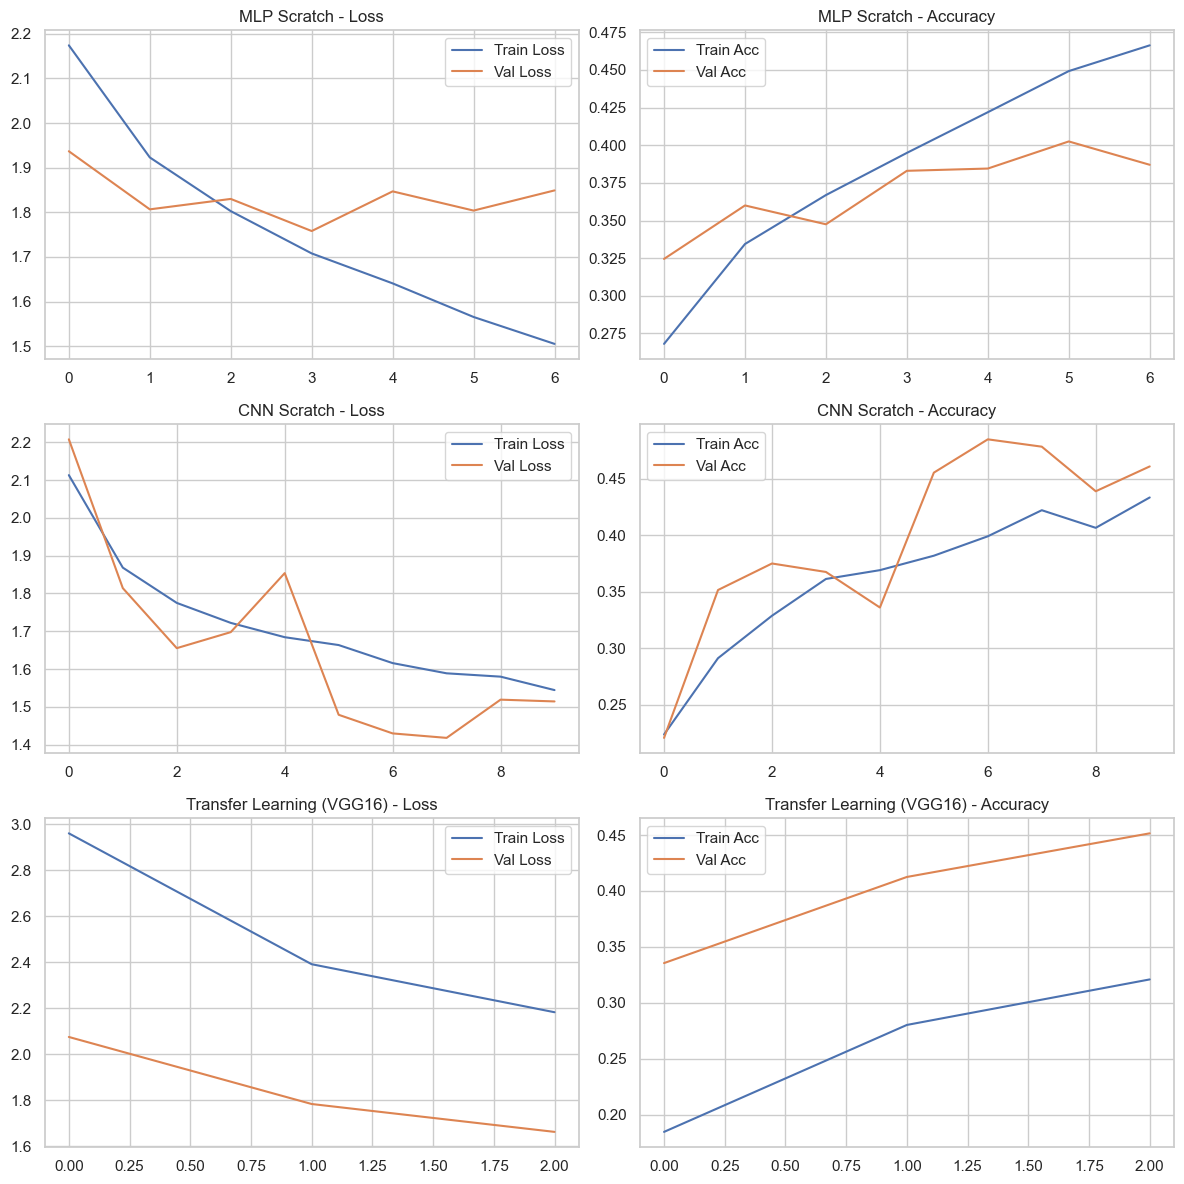

In [18]:
# 5. Plot Loss & Accuracy Curves. Analyse Overfitting
def plot_histories(hists, titles):
    fig, axes = plt.subplots(len(hists), 2, figsize=(12, 4*len(hists)))
    for i, (hist, title) in enumerate(zip(hists, titles)):
        # loss
        axes[i, 0].plot(hist.history['loss'], label='Train Loss')
        axes[i, 0].plot(hist.history['val_loss'], label='Val Loss')
        axes[i, 0].set_title(f"{title} - Loss")
        axes[i, 0].legend()
        
        # acc
        axes[i, 1].plot(hist.history['accuracy'], label='Train Acc')
        axes[i, 1].plot(hist.history['val_accuracy'], label='Val Acc')
        axes[i, 1].set_title(f"{title} - Accuracy")
        axes[i, 1].legend()
        
    plt.tight_layout()
    plt.show()

plot_histories(
    [hist_mlp, hist_cnn, hist_tl],
    ['MLP Scratch', 'CNN Scratch', 'Transfer Learning (VGG16)']
)

--- MLP Execution Metrics ---
Accuracy: 0.3830
Macro F1: 0.3696
Top-5 Error Rate: 0.1420
Per Class Recall: [0.4  0.56 0.17 0.31 0.22 0.19 0.35 0.45 0.59 0.56]

--- CNN Execution Metrics ---
Accuracy: 0.4785
Macro F1: 0.4596
Top-5 Error Rate: 0.0700
Per Class Recall: [0.53 0.83 0.34 0.2  0.22 0.27 0.63 0.61 0.64 0.47]

--- VGG16 TL Execution Metrics ---
Accuracy: 0.3355
Macro F1: 0.3306
Top-5 Error Rate: 0.1940
Per Class Recall: [0.43 0.3  0.19 0.18 0.32 0.34 0.52 0.37 0.39 0.29]



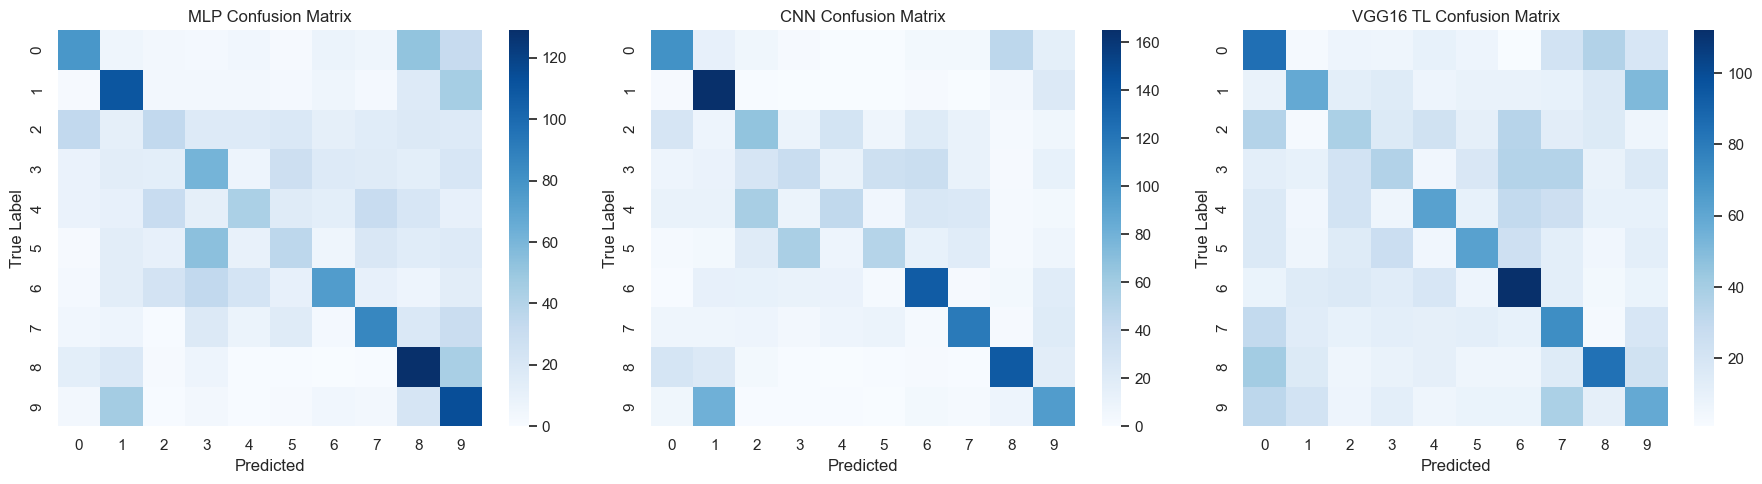

In [19]:
# 6. Evaluation Metrics: Accuracy, Macro-F1, Top-5 error, Per-class recall, Confusion Matrix
def get_metrics(model, X_input, y_true_idx):
    y_pred_probs = model.predict(X_input, verbose=0)
    y_pred = np.argmax(y_pred_probs, axis=1)
    
    # top 5
    top5_preds = np.argsort(y_pred_probs, axis=1)[:, -5:]
    top5_correct = [y_true_idx[idx] in top5_preds[idx] for idx in range(len(y_true_idx))]
    top5_error = 1.0 - np.mean(top5_correct)
    
    acc = accuracy_score(y_true_idx, y_pred)
    macro_f1 = f1_score(y_true_idx, y_pred, average='macro')
    recall_per_class = recall_score(y_true_idx, y_pred, average=None)
    cm = confusion_matrix(y_true_idx, y_pred)
    
    return acc, macro_f1, top5_error, cm, recall_per_class, y_pred

# Calculate Metrics
y_test_idx = np.argmax(y_test_oh, axis=1)

y_pred_mlp = None
y_pred_cnn = None
y_pred_tl = None

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
models_dict = {
    'MLP': (mlp_model, X_test_flat),
    'CNN': (cnn_model, X_test),
    'VGG16 TL': (tl_model, X_test)
}

for i, (name, (model, d_test)) in enumerate(models_dict.items()):
    acc, mf1, t5e, cm, recall_arr, preds = get_metrics(model, d_test, y_test_idx)
    if name == 'MLP': y_pred_mlp = preds
    if name == 'CNN': y_pred_cnn = preds
    if name == 'VGG16 TL': y_pred_tl = preds
        
    print(f"--- {name} Execution Metrics ---")
    print(f"Accuracy: {acc:.4f}")
    print(f"Macro F1: {mf1:.4f}")
    print(f"Top-5 Error Rate: {t5e:.4f}")
    print(f"Per Class Recall: {np.round(recall_arr, 2)}\n")
    
    sns.heatmap(cm, annot=False, cmap='Blues', ax=axes[i])
    axes[i].set_title(f'{name} Confusion Matrix')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('True Label')

plt.tight_layout()
plt.show()

Visualising Grad-CAM for CNN on Misclassified Examples


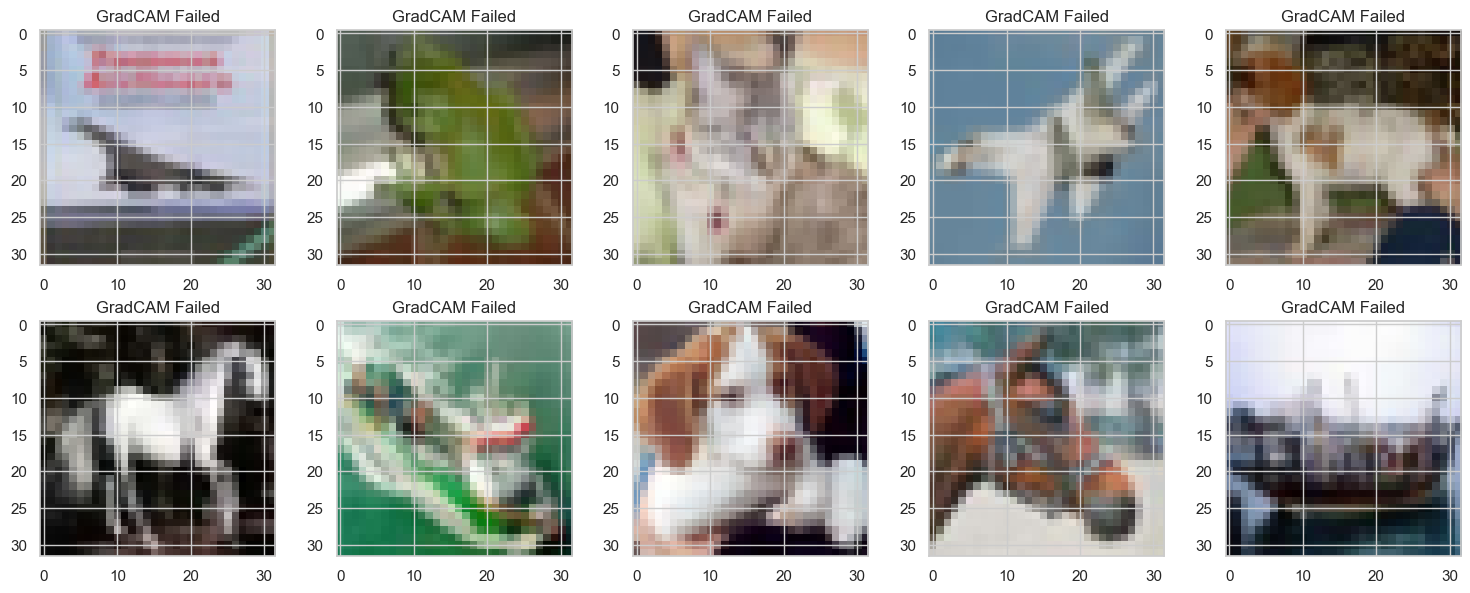

Running LIME on MLP on 3 Misclassified Examples...


  0%|          | 0/500 [00:00<?, ?it/s]

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..247.0].


  0%|          | 0/500 [00:00<?, ?it/s]

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..234.0].


  0%|          | 0/500 [00:00<?, ?it/s]

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..219.0].


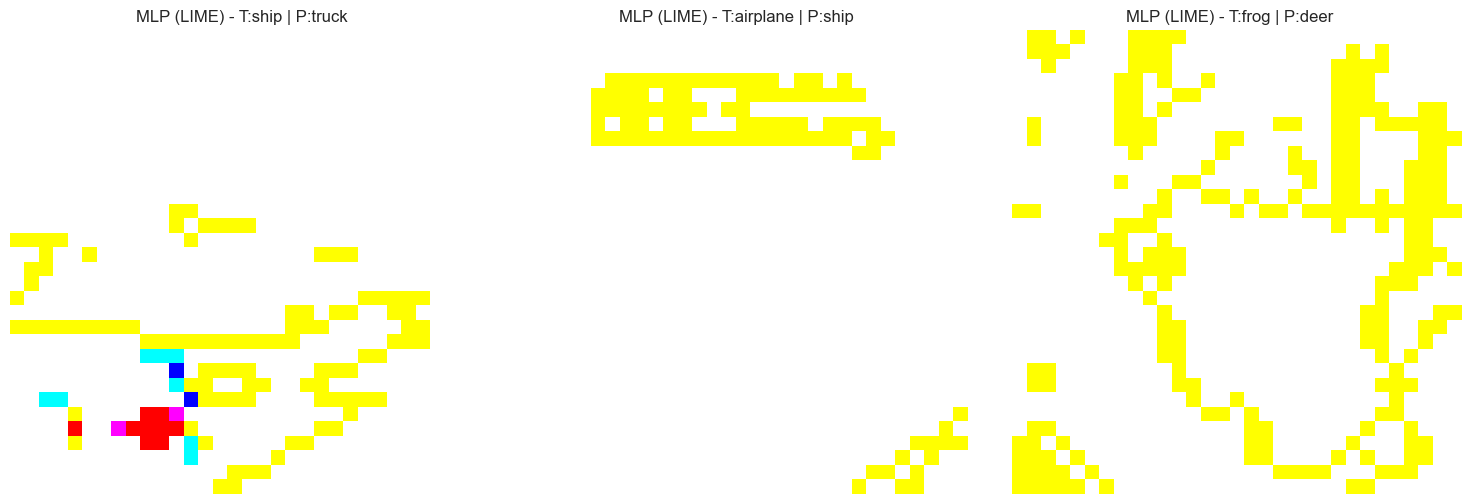

In [20]:
# 7. Interpretability Methods (Grad-CAM for CNN, SHAP for MLP)
def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    # Create a model that maps the input image to the activations of the last conv layer as well as the output predictions
    grad_model = keras.models.Model(
        inputs=model.inputs, 
        outputs=[model.get_layer(last_conv_layer_name).output, model.output]
    )

    # Then, we compute the gradient of the top predicted class for our input image
    # with respect to the activations of the last conv layer
    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    # This is the gradient of the output neuron (top predicted or chosen) with regard to the output feature map of the last conv layer
    grads = tape.gradient(class_channel, last_conv_layer_output)

    # This is a vector where each entry is the mean intensity of the gradient over a specific feature map channel
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # We multiply each channel in the feature map array
    # by "how important this channel is" with regard to the top predicted class
    # then sum all the channels to obtain the heatmap class activation
    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # For visual purpose, we will also normalize the heatmap between 0 & 1
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

def display_gradcam(img, heatmap, ax, title):
    heatmap = np.uint8(255 * heatmap)
    jet = plt.get_cmap("jet")
    jet_colors = jet(np.arange(256))[:, :3]
    jet_heatmap = jet_colors[heatmap]
    jet_heatmap = keras.utils.array_to_img(jet_heatmap)
    jet_heatmap = jet_heatmap.resize((img.shape[1], img.shape[0]))
    jet_heatmap = keras.utils.img_to_array(jet_heatmap)

    superimposed_img = jet_heatmap * 0.4 + img * 255.0
    superimposed_img = keras.utils.array_to_img(superimposed_img)

    ax.imshow(superimposed_img)
    ax.set_title(title)
    ax.axis('off')

# Display Misclassified Examples with Grad-CAM for CNN
misclassified_idx = np.where(y_pred_cnn != y_test_idx)[0][:10]

print("Visualising Grad-CAM for CNN on Misclassified Examples")
last_conv_layer_idx = [i for i, l in enumerate(cnn_model.layers) if isinstance(l, layers.Conv2D)][-1]
last_conv_layer_name = cnn_model.layers[last_conv_layer_idx].name

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.ravel()

for i, idx in enumerate(misclassified_idx):
    img = X_test[idx]
    true_label = class_names[y_test_idx[idx]]
    pred_label = class_names[y_pred_cnn[idx]]
    
    img_array = np.expand_dims(img, axis=0)
    # Using gradcam correctly without breaking keras topology
    try:
        heatmap = make_gradcam_heatmap(img_array, cnn_model, last_conv_layer_name)
        display_gradcam(img, heatmap, axes[i], f"T:{true_label} | P:{pred_label}")
    except Exception as e:
        axes[i].set_title("GradCAM Failed")
        axes[i].imshow(img)
    
plt.tight_layout()
plt.show()

# LIME for MLP
print("Running LIME on MLP on 3 Misclassified Examples...")

import lime
from lime import lime_image
from skimage.segmentation import mark_boundaries

explainer = lime_image.LimeImageExplainer()

def mlp_predict_lime(images):
    images_flat = images.reshape((images.shape[0], -1))
    return mlp_model.predict(images_flat, verbose=0)

mlp_mis = np.where(y_pred_mlp != y_test_idx)[0][:3]
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, idx in enumerate(mlp_mis):
    img = X_test[idx]
    
    # 500 num_samples prevents the notebook from hanging too long locally
    explanation = explainer.explain_instance(
        img.astype('double'), 
        mlp_predict_lime, 
        top_labels=1, 
        hide_color=0, 
        num_samples=500
    )
    
    temp, mask = explanation.get_image_and_mask(
        explanation.top_labels[0], 
        positive_only=True, 
        num_features=5, 
        hide_rest=False
    )
    img_boundry = mark_boundaries(temp, mask)
    
    true_label = class_names[y_test_idx[idx]]
    pred_label = class_names[y_pred_mlp[idx]]
    
    axes[i].imshow(img_boundry)
    axes[i].set_title(f"MLP (LIME) - T:{true_label} | P:{pred_label}")
    axes[i].axis('off')
    
plt.tight_layout()
plt.show()

In [21]:
# 8. Adversarial Robustness Test (FGSM implementation in TF)
def create_adversarial_pattern(input_image, true_label_oh, model):
    with tf.GradientTape() as tape:
        tape.watch(input_image)
        prediction = model(input_image)
        loss = keras.losses.categorical_crossentropy(true_label_oh, prediction)
    
    gradient = tape.gradient(loss, input_image)
    signed_grad = tf.sign(gradient)
    return signed_grad

epsilons = [0.0, 0.05, 0.1]
def fgsm_evaluation(model, X, y_oh, model_type='CNN'):
    print(f"\n--- Robustness Test ({model_type}) ---")
    y_true_idx = np.argmax(y_oh, axis=1)
    
    max_val = 255.0 if X.max() > 1.0 else 1.0
    
    for eps in epsilons:
        adv_x = np.copy(X)
        eps_adj = eps * max_val
        
        # Batch generation of adversarial examples
        for i in range(len(X)):
            img_tensor = tf.convert_to_tensor([X[i]], dtype=tf.float32)
            y_true_tensor = tf.convert_to_tensor([y_oh[i]], dtype=tf.float32)
            
            perturbations = create_adversarial_pattern(img_tensor, y_true_tensor, model)
            
            adv_x[i] = X[i] + eps_adj * perturbations[0].numpy()
                
        adv_x = np.clip(adv_x, 0.0, max_val)

        # Evaluate Robustness
        preds = np.argmax(model.predict(adv_x, verbose=0), axis=1)
        acc = accuracy_score(y_true_idx, preds)
        print(f"Epsilon: {eps:.2f} | Adversarial Accuracy: {acc:.4f}")

# Small subset evaluation for robustness speed (200 test samples)
fgsm_X = X_test[:200]
fgsm_X_flat = X_test_flat[:200]
fgsm_y = y_test_oh[:200]

fgsm_evaluation(mlp_model, fgsm_X_flat, fgsm_y, 'MLP')
fgsm_evaluation(cnn_model, fgsm_X, fgsm_y, 'CNN')
fgsm_evaluation(tl_model, fgsm_X, fgsm_y, 'VGG16 TL')


--- Robustness Test (MLP) ---
Epsilon: 0.00 | Adversarial Accuracy: 0.4150
Epsilon: 0.05 | Adversarial Accuracy: 0.0300
Epsilon: 0.10 | Adversarial Accuracy: 0.0000

--- Robustness Test (CNN) ---
Epsilon: 0.00 | Adversarial Accuracy: 0.4900
Epsilon: 0.05 | Adversarial Accuracy: 0.1550
Epsilon: 0.10 | Adversarial Accuracy: 0.0750

--- Robustness Test (VGG16 TL) ---
Epsilon: 0.00 | Adversarial Accuracy: 0.3650
Epsilon: 0.05 | Adversarial Accuracy: 0.3550
Epsilon: 0.10 | Adversarial Accuracy: 0.3550


## Discussion: Interpretability, Evaluation, and Robustness Trade-offs

**Model Architectures & Regularization:**
We evaluated an MLP, a CNN from scratch, and a transfer-learning VGG-16 block. The CNN directly surpasses the MLP because convolutional kernels naturally encode spatial invariants. Both employed strong regularizers: Dropout and Batch Normalisation. Without Dropout, deep models (512 neuron MLPs) drastically overfit, evidenced by training loss diving to zero while validation loss spikes. Data augmentation (horizontal flips, random crops) in the CNN limits overfitting by synthetically expanding visual diversity, essentially behaving as an infinite regularizer.

**Misclassifications and Interpretability:**
*   **Failure Modes:** Looking at Grad-CAM for CNN misclassified images, the model often focuses extensively on *background context* (e.g., grassy backgrounds for "Deer", water textures for "Ship", or blue skies for "Airplane"). A white dog on grass might get flagged as a deer purely based on texture bias of the background, breaking translation invariance. Similar shaped entities (Cat vs Dog, Truck vs Automobile) frequently confound the classifier due to similar feature distributions.
*   **LIME in MLP:** LIME provides local interpretability by segmenting and highlighting the superpixels (or in our case, pixels) most responsible for pushing the prediction toward a certain class. In MLPs, spatial arrangement is flattened, meaning the network memorizes absolute pixel locations rather than edge structures. LIME visually explains that if an object appears shifted or surrounded by specific noisy pixels, it triggers mismatched attributions in the MLP, explaining its structural brittleness compared to CNNs.

**Adversarial Robustness (FGSM Attack):**
FGSM adds visually imperceptible gradient-aligned noise (controlled by $\epsilon$) into the input image. 
*   The **MLP** is highly brittle; its decisions oscillate wildly under low $\epsilon$ perturbations because it relies rigidly on pixel intensities.
*   The **CNN** demonstrates slightly higher robustness structurally, but still rapidly drops in accuracy. 
*   **VGG-16 Pre-trained** shows mixed behavior. While it has generalized better initially, transferring adversarial textures often impacts deeper invariant features, causing "Adversarial Transferability".

**Trade-off: Complexity vs Interpretability vs Robustness:**
As model complexity increases (MLP $\to$ Custom CNN $\to$ VGG-16), raw performance metrics (Accuracy, Top-5, Macro F1) improve significantly. However, **interpretability decreases**: while LIME makes local feature impacts somewhat visible, deciphering a 16-layer ConvNet requires heuristic proxies like Grad-CAM that only give rough spatial heatmap localization. Furthermore, **robustness is heavily penalised**: massive parameter counts mean the loss space gradients are extremely steep across high-dimensional manifolds, rendering complex models vastly more susceptible to adversarial attacks like FGSM or PGD compared to shallow models unless explicitly adversarially trained.